In [1]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
train_dir = r"D:\btc5\Mri classifier\Training"
test_dir  = r"D:\btc5\Mri classifier\Testing"

IMAGE_SIZE = 224
BATCH_SIZE = 20
EPOCHS = 15
RANDOM_STATE = 42


In [3]:
class_names = sorted(os.listdir(train_dir))
print("Classes:", class_names)


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [4]:
def load_data(directory):
    paths, labels = [], []
    for label in class_names:
        label_path = os.path.join(directory, label)
        for fname in os.listdir(label_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                paths.append(os.path.join(label_path, fname))
                labels.append(label)
    return shuffle(paths, labels, random_state=RANDOM_STATE)

train_paths, train_labels = load_data(train_dir)
test_paths, test_labels = load_data(test_dir)

print(f"Training images: {len(train_paths)}")
print(f"Testing images: {len(test_paths)}")

Training images: 5712
Testing images: 1311


In [5]:
import os

def count_images(folder):
    valid_ext = ('.jpg', '.jpeg', '.png')
    return len([f for f in os.listdir(folder) if f.lower().endswith(valid_ext)])

train_path = r"D:\btc5\Mri classifier\Training"
test_path = r"D:\btc5\Mri classifier\Testing"

print("training -", sum([count_images(os.path.join(train_path, c)) for c in os.listdir(train_path)]))

for cls in os.listdir(train_path):
    cls_path = os.path.join(train_path, cls)
    print(f"    {cls} - {count_images(cls_path)}")

print("\ntesting -", sum([count_images(os.path.join(test_path, c)) for c in os.listdir(test_path)]))

for cls in os.listdir(test_path):
    cls_path = os.path.join(test_path, cls)
    print(f"    {cls} - {count_images(cls_path)}")

training - 5712
    glioma - 1321
    meningioma - 1339
    notumor - 1595
    pituitary - 1457

testing - 1311
    glioma - 300
    meningioma - 306
    notumor - 405
    pituitary - 300


In [6]:
def encode_label(labels):
    return np.array([class_names.index(label) for label in labels])

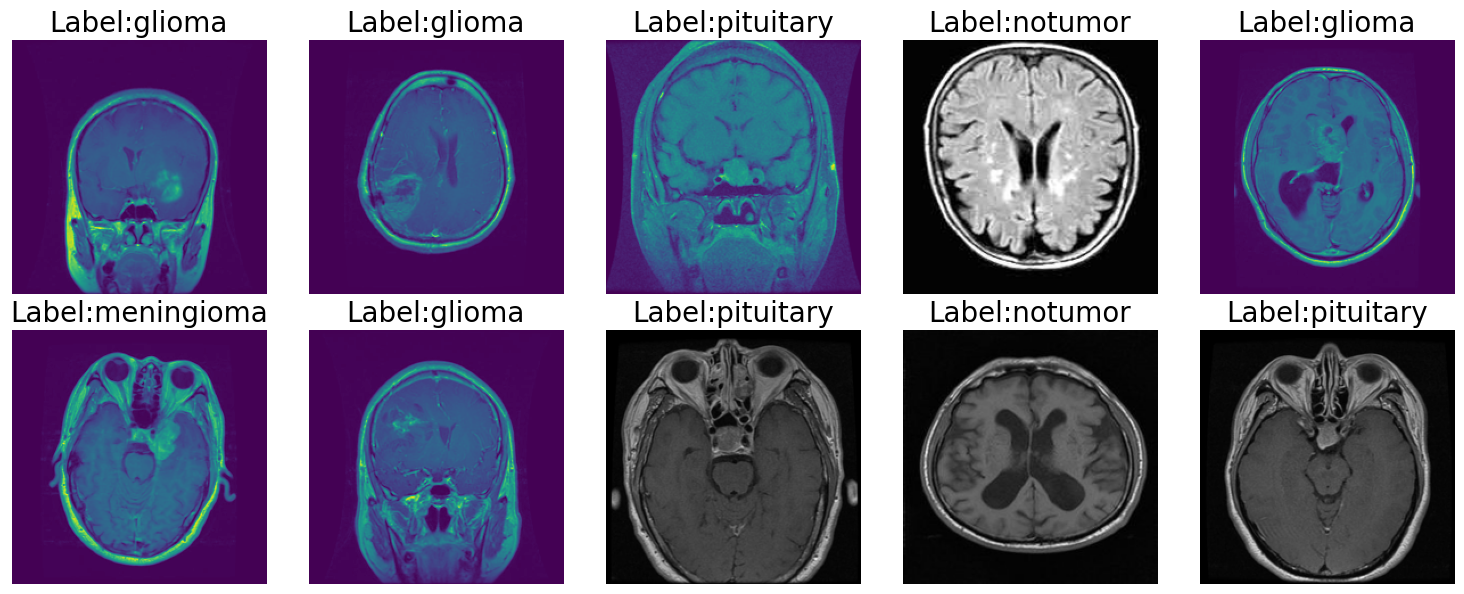

In [7]:
import matplotlib.pyplot as plt
#select random indices for 10 images
random_indices=random.sample(range(len(train_paths)),10)
#create a figure to display images in 2 rows
fig, axes=plt.subplots(2,5,figsize=(15,6))
axes=axes.ravel()   
#Loop through the random indices  and display images
for i,idx in enumerate(random_indices):
    img_path=train_paths[idx]
    img=Image.open(img_path)
    img=img.resize((224,224))
    #Display images
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(f"Label:{train_labels[idx]}",fontsize=20)
plt.tight_layout()
plt.show()

In [8]:
def augment_image(image):
    image = Image.fromarray(np.uint8(image))
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8,1.2))
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8,1.2))
    return np.array(image)


In [9]:
def open_images(paths, augment=False):
    images = []
    for path in paths:
        img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        img = img_to_array(img)

        if augment and random.random() < 0.5:
            img = augment_image(img)

        img = preprocess_input(img)
        images.append(img)

    return np.array(images)

In [10]:
def datagen(paths, labels, batch_size, augment=False):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths, augment)
            batch_labels = encode_label(labels[i:i + batch_size])
            yield batch_images, batch_labels


In [11]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.2,
    stratify=train_labels,
    random_state=RANDOM_STATE
)

In [12]:
base_model = VGG16(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze most layers
for layer in base_model.layers[:-10]:
    layer.trainable = False

model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 25088)             0         
                                                                 
 dropout (Dropout)           (None, 25088)             0         
                                                                 
 dense (Dense)               (None, 128)               3211392   
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 4)                 516       
                                                                 
Total params: 17,926,596
Trainable params: 16,781,188
No

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [14]:
history = model.fit(
    datagen(train_paths, train_labels, BATCH_SIZE, augment=True),
    validation_data=datagen(val_paths, val_labels, BATCH_SIZE),
    steps_per_epoch=len(train_paths)//BATCH_SIZE,
    validation_steps=len(val_paths)//BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

Epoch 1/15
228/228 [==============================] - 948s 4s/step - loss: 1.2142 - accuracy: 0.5721 - val_loss: 0.5224 - val_accuracy: 0.8061
Epoch 2/15
228/228 [==============================] - 1066s 5s/step - loss: 0.6148 - accuracy: 0.7615 - val_loss: 0.3982 - val_accuracy: 0.8491
Epoch 3/15
228/228 [==============================] - 1110s 5s/step - loss: 0.4186 - accuracy: 0.8455 - val_loss: 0.2438 - val_accuracy: 0.9211
Epoch 4/15
228/228 [==============================] - 1103s 5s/step - loss: 0.3239 - accuracy: 0.8815 - val_loss: 0.2586 - val_accuracy: 0.9281
Epoch 5/15
228/228 [==============================] - 1081s 5s/step - loss: 0.2470 - accuracy: 0.9160 - val_loss: 0.1752 - val_accuracy: 0.9465
Epoch 6/15
228/228 [==============================] - 1073s 5s/step - loss: 0.2324 - accuracy: 0.9165 - val_loss: 0.1614 - val_accuracy: 0.9509
Epoch 7/15
228/228 [==============================] - 1022s 4s/step - loss: 0.1741 - accuracy: 0.9398 - val_loss: 0.2323 - val_accuracy: 

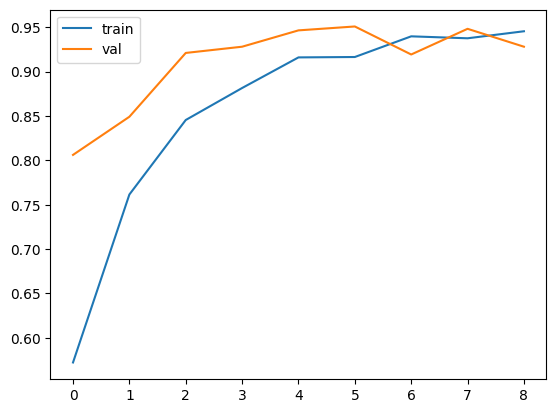

In [24]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.show()


41/41 [==============================] - 112s 3s/step
              precision    recall  f1-score   support

           0       0.99      0.82      0.90       300
           1       0.79      0.91      0.85       306
           2       0.98      0.97      0.98       405
           3       0.94      0.97      0.96       300

    accuracy                           0.92      1311
   macro avg       0.93      0.92      0.92      1311
weighted avg       0.93      0.92      0.92      1311



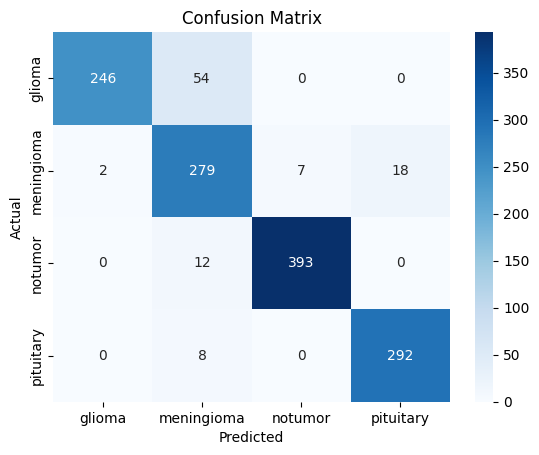

In [34]:
test_images = open_images(test_paths)
test_labels_encoded = encode_label(test_labels)

preds = model.predict(test_images)
y_pred = np.argmax(preds, axis=1)

print(classification_report(test_labels_encoded, y_pred))

conf_matrix = confusion_matrix(test_labels_encoded, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.title("Confusion Matrix")
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.show()


In [17]:
model.save("model.h5")

In [18]:
def temperature_scaling(probs, T=1.5):
    log_probs = np.log(probs + 1e-10)
    scaled = log_probs / T
    exp = np.exp(scaled)
    return exp / np.sum(exp)

In [26]:
def predict_tumor(image_path):
    img = load_img(image_path, target_size=(224,224))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)

    raw_preds = model.predict(img)[0]
    preds = temperature_scaling(raw_preds)

    idx = np.argmax(preds)
    confidence = float(preds[idx])
    label = class_names[idx]

    if confidence < 0.65:
        result = "Unclear MRI image - please retake or consult doctor"
    elif label == "notumor":
        result = "No tumor detected"
    else:
        result = f"Tumor detected: {label} (consult doctor)"

    return result, confidence, label

In [27]:
def detect_and_display(image_path):
    result, confidence, label = predict_tumor(image_path)

    img = Image.open(image_path)

    plt.imshow(img)
    plt.title(f"{result}\nConfidence: {confidence*100:.2f}%")
    plt.axis("off")
    plt.show()

1/1 [==============================] - 0s 289ms/step


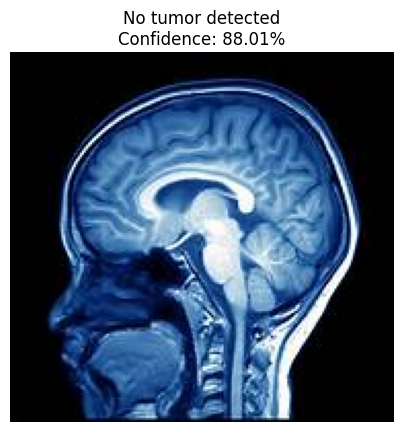

In [28]:
img_path=r"D:\btc5\Sample\OIP.jpg"
detect_and_display(img_path)

1/1 [==============================] - 0s 110ms/step


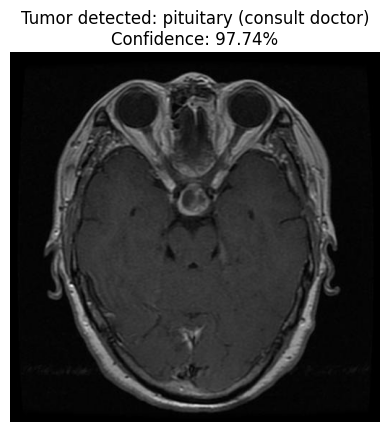

In [29]:
img_path=r"D:\btc5\Mri classifier\Testing\pituitary\Te-pi_0060.jpg"
detect_and_display(img_path)

1/1 [==============================] - 0s 110ms/step


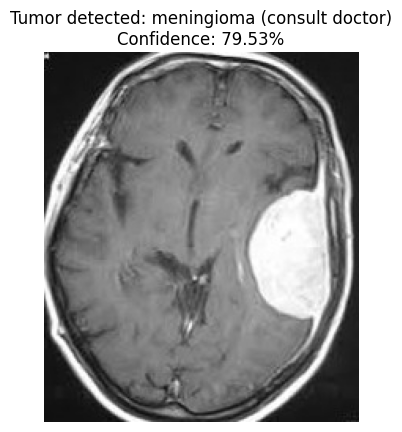

In [33]:
img_path=r'D:\btc5\Mri classifier\Testing\meningioma\Te-me_0098.jpg'
detect_and_display(img_path)